In [1]:
import colorcet as cc
import gstools as gs
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from context_flux_no.simulations.pde.euler import Euler2D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import GaussianRandomField, GaussianRandomField2D

2026-08-27 03:00:52,662 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


W0827 03:00:54.277278  772835 gpu_helpers.cc:80] Unable to enable peer access between GPUs 0 and 9; status: INTERNAL: failed to enable peer access from 0x148b94c64960 to 0x148b98c02960: INTERNAL: CUDA error: : CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
W0827 03:00:54.282321  772835 gpu_helpers.cc:80] Unable to enable peer access between GPUs 1 and 9; status: INTERNAL: failed to enable peer access from 0x148b9cc02c90 to 0x148b98c02960: INTERNAL: CUDA error: : CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
W0827 03:00:54.286741  772835 gpu_helpers.cc:80] Unable to enable peer access between GPUs 2 and 9; status: INTERNAL: failed to enable peer access from 0x148ba8c05650 to 0x148b98c02960: INTERNAL: CUDA error: : CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
W0827 03:00:54.294427  772835 gpu_helpers.cc:80] Unable to enable peer access between GPUs 3 and 9; status: INTERNAL: failed to enable peer access from 0x148ba0c02c70 to 0x148b98c02960: INTE

In [2]:
keys = jax.random.split(jax.random.key(1), 4)

euler = Euler2D(gamma=1.4)
key = jax.random.key(1)


grf = GaussianRandomField2D(gs.Gaussian(dim=2, var=1.0, len_scale=0.3))


def initial_condition(xs, key=jax.random.key(0)):
    rho_key, ux_key, uy_key, energy_key = jax.random.split(key, 4)

    rho_field = np.asarray(grf.sample(xs, rho_key))
    ux_field = np.asarray(grf.sample(xs, ux_key))
    uy_field = np.asarray(grf.sample(xs, uy_key))
    energy_field = np.asarray(grf.sample(xs, energy_key))

    # 밀도는 항상 양수
    rho = 1.0 + 0.1 * np.tanh(rho_field)

    velocity_x = 0.05 * np.tanh(ux_field)
    velocity_y = 0.05 * np.tanh(uy_field)

    momentum_x = rho * velocity_x
    momentum_y = rho * velocity_y

    # 내부에너지 밀도를 항상 양수로 설정
    internal_energy = 2.5 + 0.25 * np.tanh(energy_field)

    kinetic_energy = 0.5 * rho * (velocity_x**2 + velocity_y**2)
    total_energy = internal_energy + kinetic_energy

    # (rho, rho*u, rho*v, E)
    return np.stack(
        (
            rho,
            momentum_x,
            momentum_y,
            total_energy,
        ),
        axis=0,
    )

In [2]:
grf = GaussianRandomField(
    covariance_fns=[
        gs.Gaussian(dim=2, len_scale=0.2),
        gs.Gaussian(dim=2, len_scale=0.2),
        gs.Gaussian(dim=2, len_scale=0.2),
        gs.Gaussian(dim=2, len_scale=0.2),
    ],
    means=[2, 0, 0, 2],
    scales=[0.2, 0.6, 0.6, 0.2],
)

In [3]:
u_test = grf.sample((np.linspace(0, 1, 128), np.linspace(0, 1, 128)), jax.random.key(0))

In [4]:
u_test.shape

(4, 128, 128)

(array([ 15.,  23.,  57.,  84.,  99., 126., 154., 140., 180., 161., 152.,
        173., 183., 178., 193., 190., 217., 208., 229., 235., 231., 254.,
        269., 284., 258., 353., 301., 376., 397., 439., 438., 418., 363.,
        347., 383., 384., 292., 294., 303., 263., 283., 260., 278., 287.,
        277., 291., 284., 251., 220., 223., 213., 201., 196., 162., 124.,
        149., 148., 126., 128.,  96.,  87.,  98.,  97.,  94.,  80.,  82.,
         83.,  77.,  87.,  66.,  76.,  75.,  76.,  60.,  71.,  76.,  67.,
         63.,  66.,  66.,  58.,  63.,  62.,  55.,  62.,  55.,  66.,  49.,
         64.,  49.,  55.,  51.,  52.,  52.,  53.,  51.,  35.,  21.,  19.,
         24.]),
 array([0.00979988, 0.02476615, 0.03973242, 0.05469869, 0.06966496,
        0.08463123, 0.0995975 , 0.11456377, 0.12953004, 0.14449631,
        0.15946258, 0.17442886, 0.18939513, 0.2043614 , 0.21932767,
        0.23429394, 0.24926021, 0.26422648, 0.27919275, 0.29415902,
        0.30912529, 0.32409156, 0.33905783, 0.

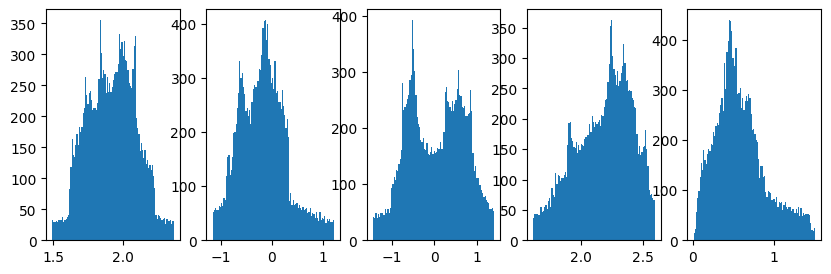

In [5]:
gamma = 1.4
mach = np.hypot(u_test[1], u_test[2]) / np.sqrt(gamma * u_test[3] / u_test[0])

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(u_test.shape[0]):
    axes[i].hist(u_test[i].flatten(), bins=100)
axes[-1].hist(mach.flatten(), bins=100)

In [6]:
sol = euler.solve(
    initial_condition,
    ((0.0, 1.0), (0.0, 1.0)),
    (128, 128),
    (0.0, 0.5),
    100,
)

NameError: name 'euler' is not defined

In [50]:
sol

NameError: name 'sol' is not defined

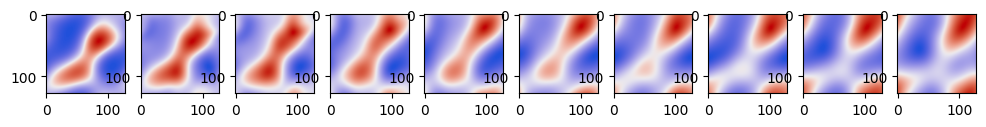

In [7]:
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sol["values"][0, i * 10, 0], cmap=cc.cm.coolwarm)

In [7]:
euler_claw = Euler2D(gamma=1.5)
sol_claw = euler_claw.solve(
    lambda xs: grf.sample(xs, key=jax.random.key(10)),
    ((0.0, 1.0), (0.0, 1.0)),
    (128, 128),
    (0.0, 0.5),
    100,
    "periodic",
)

2026-08-27 03:01:18,467 INFO CLAW: Solution 0 computed for time t=0.000000
2026-08-27 03:01:18,483 INFO CLAW: Solution 1 computed for time t=0.005000
2026-08-27 03:01:18,493 INFO CLAW: Solution 2 computed for time t=0.010000
2026-08-27 03:01:18,504 INFO CLAW: Solution 3 computed for time t=0.015000
2026-08-27 03:01:18,514 INFO CLAW: Solution 4 computed for time t=0.020000
2026-08-27 03:01:18,524 INFO CLAW: Solution 5 computed for time t=0.025000
2026-08-27 03:01:18,535 INFO CLAW: Solution 6 computed for time t=0.030000
2026-08-27 03:01:18,545 INFO CLAW: Solution 7 computed for time t=0.035000
2026-08-27 03:01:18,555 INFO CLAW: Solution 8 computed for time t=0.040000
2026-08-27 03:01:18,566 INFO CLAW: Solution 9 computed for time t=0.045000
2026-08-27 03:01:18,576 INFO CLAW: Solution 10 computed for time t=0.050000
2026-08-27 03:01:18,586 INFO CLAW: Solution 11 computed for time t=0.055000
2026-08-27 03:01:18,596 INFO CLAW: Solution 12 computed for time t=0.060000
2026-08-27 03:01:18,60

In [8]:
sol_claw[0].shape

(101, 4, 128, 128)

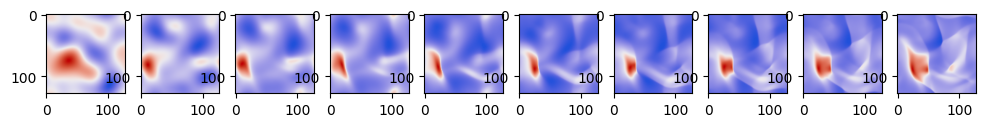

In [9]:
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sol_claw[0][i * 10, 0], cmap=cc.cm.coolwarm)

In [10]:
dataset = generate_dataset(
    dataset_name="2d_euler_test",
    n_coeffs=10,
    n_ics_per_coeff=10,
    pde_factory=Euler2D,
    initial_condition_fn=grf.sample,
    coeff_range_dict={"gamma": (1.2, 1.5)},
    x_spans=((0, 1), (0, 1)),
    Nxs=(128, 128),
    t_span=(0, 0.5),
    Nt=100,
    coeff_sampling_strategy="linspace",
    seed=0,
)

  0%|          | 0/10 [00:00<?, ?it/s]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/zarr/core/group.py:2779: ZarrUserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(
/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/zarr/core/array.py:4480: ZarrUserWarning: Automatic shard shape inference is experimental and may change without notice.
  outer_chunks, inner = resolve_outer_and_inner_chunks(
100%|██████████| 10/10 [04:30<00:00, 27.05s/it]


In [11]:
dataset[10]

{'scalars': {'gamma': array(1.2333333, dtype=float32)},
 't0_fields': {'rho': array([[[1.8836414, 1.9210105, 1.9582238, ..., 1.7733364, 1.8095367,
           1.8463929],
          [1.8935261, 1.9309818, 1.9682649, ..., 1.7828915, 1.8192105,
           1.8561776],
          [1.9030724, 1.9405233, 1.9777907, ..., 1.792405 , 1.828741 ,
           1.8657194],
          ...,
          [1.8530297, 1.8896432, 1.9261825, ..., 1.7453363, 1.7806227,
           1.8166038],
          [1.8632759, 1.9002181, 1.9370538, ..., 1.7544599, 1.7901376,
           1.8264947],
          [1.8735205, 1.9107167, 1.9477789, ..., 1.7638273, 1.799812 ,
           1.836463 ]],
  
         [[1.8641713, 1.8992367, 1.9339739, ..., 1.7595958, 1.7940927,
           1.8290384],
          [1.8763814, 1.9115189, 1.9463023, ..., 1.7714603, 1.8061008,
           1.8411539],
          [1.8883792, 1.9235132, 1.9582785, ..., 1.7830911, 1.8179079,
           1.8531221],
          ...,
          [1.827563 , 1.8621691, 1.8963298, 

In [12]:
await dataset.root.store.getsize_prefix("") / 1e9

1.958427747

In [13]:
dataset.root.tree()

/
├── dimensions
│   ├── time (101,) float32
│   ├── x (128,) float32
│   └── y (128,) float32
├── scalars
│   └── gamma (100,) float32
├── t0_fields
│   ├── E (100, 101, 128, 128) float32
│   └── rho (100, 101, 128, 128) float32
├── t1_fields
│   └── m (100, 101, 128, 128, 2) float32
└── t2_fields

In [14]:
np.unique(dataset.root["scalars"]["gamma"][:])

array([1.2      , 1.2333333, 1.2666668, 1.3      , 1.3333335, 1.3666667,
       1.4      , 1.4333334, 1.4666667, 1.5      ], dtype=float32)

In [ ]:
dataset = generate_dataset(
    n_coeffs=50,
    n_ics_per_coeff=500,
    pde_factory=Euler2D,
    initial_condition_fn=initial_condition,
    coeff_range_dict={"gamma": (1.2, 5 / 3)},
    x_span=((0, 1), (0, 1)),
    Nx=(50, 50),
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)

  0%|                                                                                                                                                                     | 0/50 [00:00<?, ?it/s]

In [8]:
dataset["values"].nbytes / 1e9

0.101

In [1]:
dataset["values"].shape

NameError: name 'dataset' is not defined

In [ ]:
from pathlib import Path


savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "2d_euler_training_50_500.hdf5")

.venv/bin/python ./scripts/training/train_multiphysics_2d.py \
  data=2d_scalar \
  model=hyperfluxno_2d_scalar_global \
  training.context_length=10 \
  training.batch_size=32 \
  training.optimizer.learning_rate.warmup_steps=10000 \
  training.optimizer.learning_rate.decay_steps=40000 \
  hydra.launcher.partition=h100 \
  hydra.launcher.cpus_per_task=12 \
  hydra.launcher.mem_gb=350 \
  model.key.seed=10 \
  --multirun